In [1]:
import matplotlib.pyplot as plt
import numpy as np
from numpy import pi as pi
from numpy import sqrt as sqrt
from qutip import *

In [2]:
# parameter
wr = 2.0 * 2 * pi      # resonator frequency
wq1 = 3.0 * 2 * pi      # qubit frequency
wq2 = 3.5 * 2 * pi
g1 = 0.1 * 2 * pi   # parameter in the dispersive hamiltonian
g2 = 0.1 * 2 * pi
N = 15              # number of fock states

# detuning and shift
delta_1 = wq1 - wr
delta_2 = wq2 - wr
chi_1 = g1**2 / delta_1
chi_2 = g2**2 / delta_2

In [3]:
# Operators
a = tensor(destroy(N), qeye(2), qeye(2))  # cavity annihilation
sm1 = tensor(qeye(N), destroy(2), qeye(2))  # qubit 1 lowering
sm2 = tensor(qeye(N), qeye(2), destroy(2))  # qubit 2 lowering

sz1 = tensor(qeye(N), sigmaz(), qeye(2))
sz2 = tensor(qeye(N), qeye(2), sigmaz())

# Qubit Hamiltonians
Hq1 = (wq1 / 2) * sz1
Hq2 = (wq2 / 2) * sz2

# Cavity Hamiltonian
Hr = wr * a.dag() * a

# Interaction Hamiltonian
Hint1 = g1 * (a + a.dag()) * (sm1 + sm1.dag())
Hint2 = g2 * (a + a.dag()) * (sm2 + sm2.dag())

# Total Hamiltonian
H = Hq1 + Hq2 + Hr + Hint1 + Hint2

# Correlation of the resonator
Explore how the resonator peak is split and shiften up and down due to the superposition of 0 and 1 states of the qubit.

In [14]:
# Initial state, resonator - qubit 1 - qubit 2
# qubit state 10
psi0 = tensor(coherent(N,3), basis(2,1), basis(2,0))

In [5]:
tlist = np.linspace(0, 100, 5000)

In [6]:
corr_vec = correlation_2op_1t(H, psi0, tlist, [], a.dag(), a, solver = 'me')

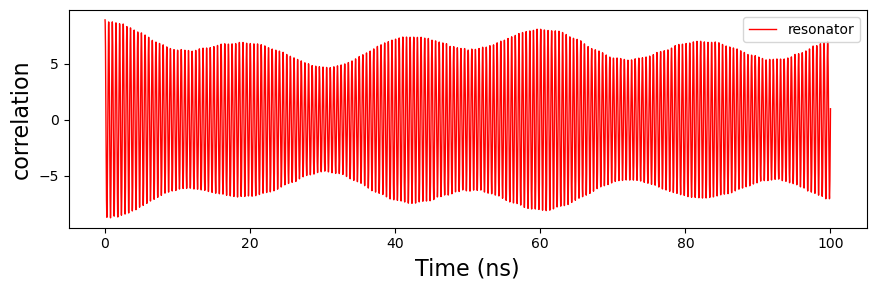

In [7]:
# Correlation function for the resonator

fig, ax = plt.subplots(1, 1, figsize=(9,3))
ax.plot(tlist, np.real(corr_vec), 'r', linewidth=1, label="resonator")
ax.set_ylabel("correlation", fontsize=16)
ax.set_xlabel("Time (ns)", fontsize=16)
ax.legend()
fig.tight_layout()

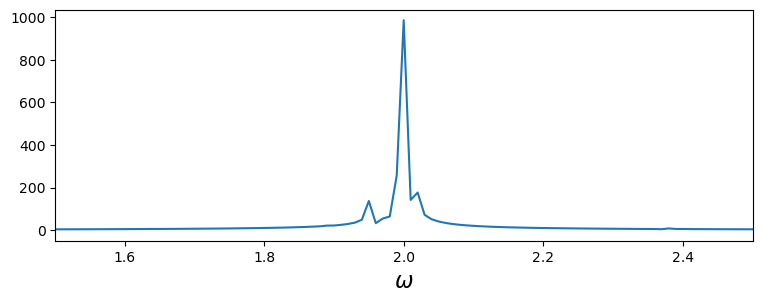

In [8]:
# Spectrum of the resonator

w, S = spectrum_correlation_fft(tlist, corr_vec)

fig, ax = plt.subplots(figsize=(9,3))
ax.plot(w / (2 * pi), abs(S))
ax.set_xlabel(r'$\omega$', fontsize=16)
ax.set_xlim(wr / (2 * pi) - 0.5, wr / (2 * pi) + 0.5);

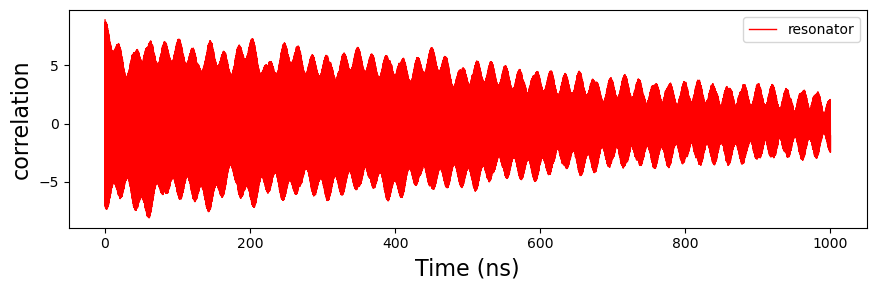

In [12]:
# Correlation function for the resonator, increasing time
tlist_2 = np.linspace(0, 1000, 10000)
corr_vec_2 = correlation_2op_1t(H, psi0, tlist_2, [], a.dag(), a, solver = 'me')

fig, ax = plt.subplots(1, 1, figsize=(9,3))
ax.plot(tlist_2, np.real(corr_vec_2), 'r', linewidth=1, label="resonator")
ax.set_ylabel("correlation", fontsize=16)
ax.set_xlabel("Time (ns)", fontsize=16)
ax.legend()
fig.tight_layout()

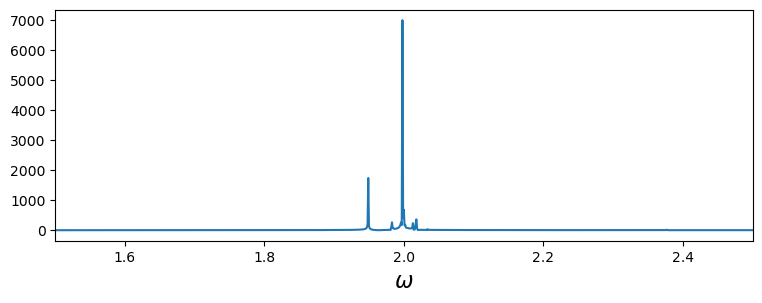

In [13]:
# Spectrum of the resonator, increasing time

w, S = spectrum_correlation_fft(tlist_2, corr_vec_2)

fig, ax = plt.subplots(figsize=(9,3))
ax.plot(w / (2 * pi), abs(S))
ax.set_xlabel(r'$\omega$', fontsize=16)
ax.set_xlim(wr / (2 * pi) - 0.5, wr / (2 * pi) + 0.5);

In [28]:
# qubit state 01
psi1 = tensor(coherent(N,3), basis(2,0), basis(2,1))

# qubit state 00
psi2 = tensor(coherent(N,3), basis(2,0), basis(2,0))

# qubit state 11
psi3 = tensor(coherent(N,3), basis(2,1), basis(2,1))

# correlation function for the resonator
corr_vec_01 = correlation_2op_1t(H, psi1, tlist_2, [], a.dag(), a, solver = 'me')
corr_vec_00 = correlation_2op_1t(H, psi2, tlist_2, [], a.dag(), a, solver = 'me')
corr_vec_11 = correlation_2op_1t(H, psi3, tlist_2, [], a.dag(), a, solver = 'me')

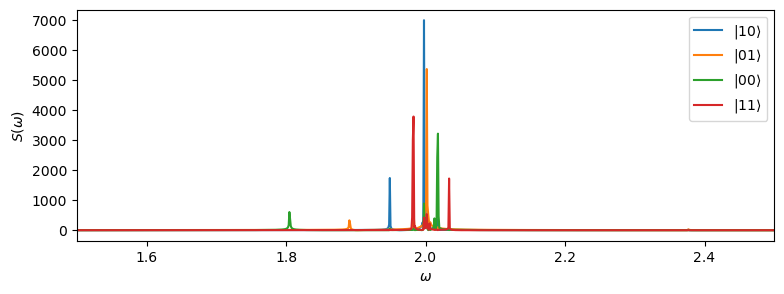

In [19]:
# Spectrum of the resonator
w01, S01 = spectrum_correlation_fft(tlist_2, corr_vec_01)
w00, S00 = spectrum_correlation_fft(tlist_2, corr_vec_00)
w11, S11 = spectrum_correlation_fft(tlist_2, corr_vec_11)

fig, ax = plt.subplots(figsize=(9,3))
ax.plot(w / (2 * pi), abs(S), label = r"$|10\rangle$")
ax.plot(w01 / (2 * pi), abs(S01), label = r"$|01\rangle$")
ax.plot(w00 / (2 * pi), abs(S00), label = r"$|00\rangle$")
ax.plot(w11 / (2 * pi), abs(S11), label = r"$|11\rangle$")
ax.set_xlabel(r'$\omega$')
ax.set_ylabel(r'$S(\omega)$')
ax.legend()
ax.set_xlim(wr / (2 * pi) - 0.5, wr / (2 * pi) + 0.5);

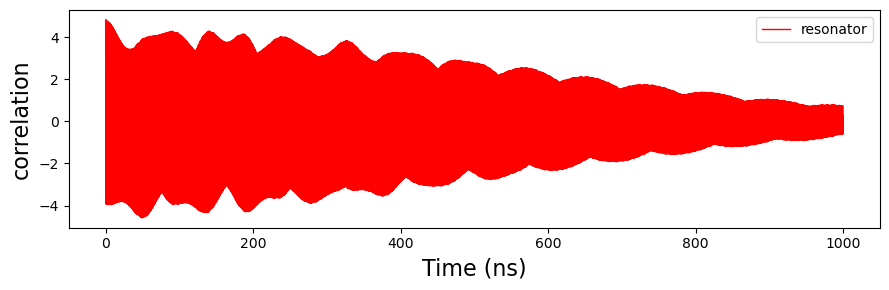

In [26]:
# increasing the coherent amplitude (photon states)
psi_10 = tensor(coherent(N,10), basis(2,1), basis(2,0))
tlist_10 = np.linspace(0, 1000, 5000)

corr_vec_10 = correlation_2op_1t(H, psi_10, tlist_10, [], a.dag(), a, solver = 'me')

fig, ax = plt.subplots(1, 1, figsize=(9,3))
ax.plot(tlist_10, np.real(corr_vec_10), 'r', linewidth=1, label="resonator")
ax.set_ylabel("correlation", fontsize=16)
ax.set_xlabel("Time (ns)", fontsize=16)
ax.legend()
fig.tight_layout()

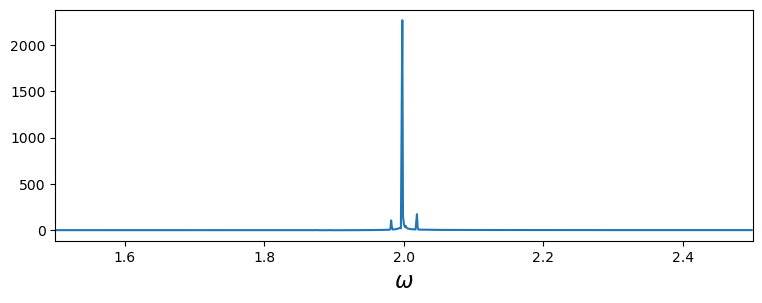

In [27]:
w_10, S_10 = spectrum_correlation_fft(tlist_10, corr_vec_10)

fig, ax = plt.subplots(figsize=(9,3))
ax.plot(w_10 / (2 * pi), abs(S_10))
ax.set_xlabel(r'$\omega$', fontsize=16)
ax.set_xlim(wr / (2 * pi) - 0.5, wr / (2 * pi) + 0.5);

In [29]:
# qubit state 01
psi_1 = tensor(coherent(N,10), basis(2,0), basis(2,1))

# qubit state 00
psi_2 = tensor(coherent(N,10), basis(2,0), basis(2,0))

# qubit state 11
psi_3 = tensor(coherent(N,10), basis(2,1), basis(2,1))

# correlation function for the resonator
corr_vec01 = correlation_2op_1t(H, psi_1, tlist_10, [], a.dag(), a, solver = 'me')
corr_vec00 = correlation_2op_1t(H, psi_2, tlist_10, [], a.dag(), a, solver = 'me')
corr_vec11 = correlation_2op_1t(H, psi_3, tlist_10, [], a.dag(), a, solver = 'me')

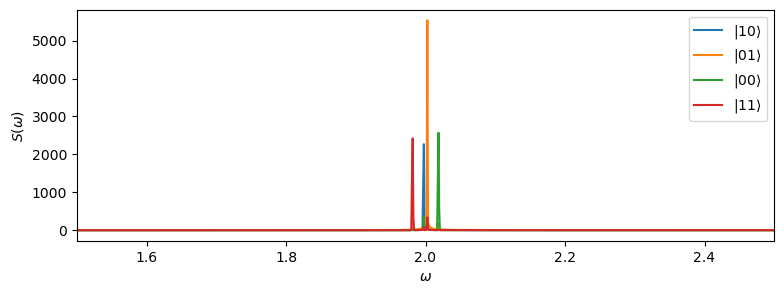

In [30]:
w_01, S_01 = spectrum_correlation_fft(tlist_10, corr_vec01)
w_00, S_00 = spectrum_correlation_fft(tlist_10, corr_vec00)
w_11, S_11 = spectrum_correlation_fft(tlist_10, corr_vec11)

fig, ax = plt.subplots(figsize=(9,3))
ax.plot(w_10 / (2 * pi), abs(S_10), label = r"$|10\rangle$")
ax.plot(w_01 / (2 * pi), abs(S_01), label = r"$|01\rangle$")
ax.plot(w_00 / (2 * pi), abs(S_00), label = r"$|00\rangle$")
ax.plot(w_11 / (2 * pi), abs(S_11), label = r"$|11\rangle$")
ax.set_xlabel(r'$\omega$')
ax.set_ylabel(r'$S(\omega)$')
ax.legend()
ax.set_xlim(wr / (2 * pi) - 0.5, wr / (2 * pi) + 0.5);

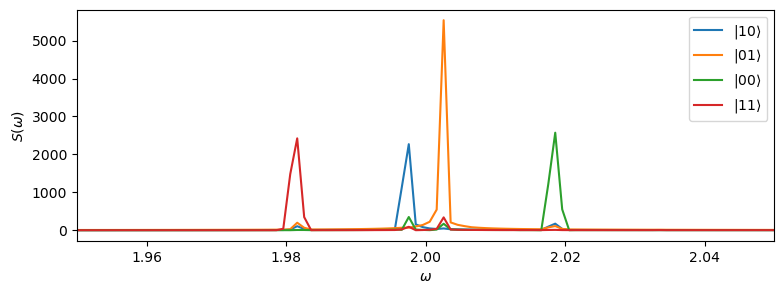

In [33]:
fig, ax = plt.subplots(figsize=(9,3))
ax.plot(w_10 / (2 * pi), abs(S_10), label = r"$|10\rangle$")
ax.plot(w_01 / (2 * pi), abs(S_01), label = r"$|01\rangle$")
ax.plot(w_00 / (2 * pi), abs(S_00), label = r"$|00\rangle$")
ax.plot(w_11 / (2 * pi), abs(S_11), label = r"$|11\rangle$")
ax.set_xlabel(r'$\omega$')
ax.set_ylabel(r'$S(\omega)$')
ax.legend()
ax.set_xlim(wr / (2 * pi) - 0.05, wr / (2 * pi) + 0.05);

In [34]:
print(chi_1, chi_2)

0.06283185307179585 0.041887902047863905


# Correlation of the qubit

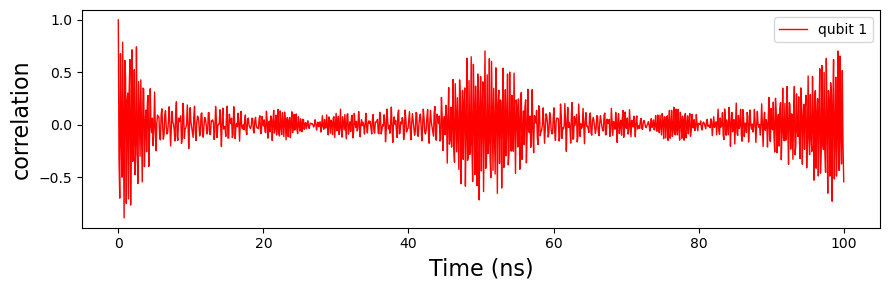

In [37]:
# Correlation function of qubit 1
psi0 = tensor(coherent(N,3), basis(2,1), basis(2,0))
tlist = np.linspace(0, 100, 1000)
corr = correlation_2op_1t(H, psi0, tlist, [], sm1.dag(), sm1, solver = 'me')

fig, ax = plt.subplots(1, 1, figsize=(9,3))
ax.plot(tlist, np.real(corr), 'r', linewidth=1, label="qubit 1")
ax.set_ylabel("correlation", fontsize=16)
ax.set_xlabel("Time (ns)", fontsize=16)
ax.legend()
fig.tight_layout()

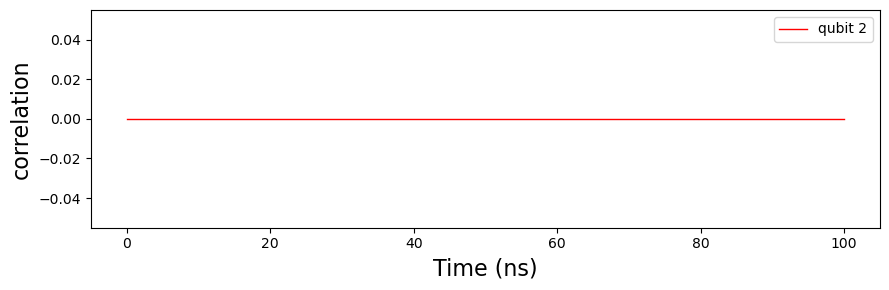

In [38]:
# Correlation function of qubit 2
corr2 = correlation_2op_1t(H, psi0, tlist, [], sm2.dag(), sm2, solver = 'me')

fig, ax = plt.subplots(1, 1, figsize=(9,3))
ax.plot(tlist, np.real(corr2), 'r', linewidth=1, label="qubit 2")
ax.set_ylabel("correlation", fontsize=16)
ax.set_xlabel("Time (ns)", fontsize=16)
ax.legend()
fig.tight_layout()

Text(0, 0.5, '$S(\\omega)$')

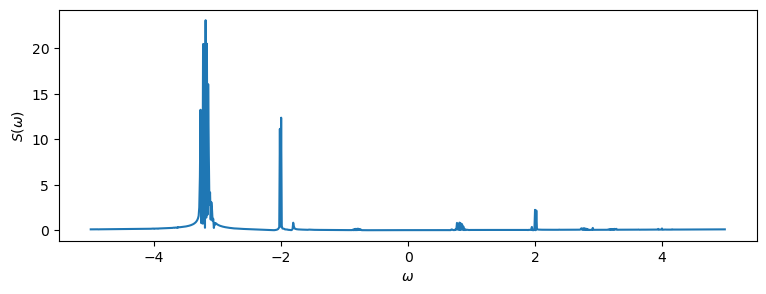

In [44]:
# Spectrum of qubit 1
w_qubit_1, S_qubit_1 = spectrum_correlation_fft(tlist, corr)

fig, ax = plt.subplots(figsize=(9,3))
ax.plot(w_qubit_1 / (2 * pi), abs(S_qubit_1))
ax.set_xlabel(r'$\omega$')
ax.set_ylabel(r'$S(\omega)$')